# Classification tutorial

This tutorial presents the classification workflow in `Exception-Rules`.

The example uses the `mushroom` dataset. The goal is to train a rule-based classifier, inspect the generated rules, and evaluate predictions.

The file `mushroom.arff` should be located in the same directory as this notebook.


## Install dependencies


In [1]:
# %pip install matplotlib

## Dataset

The `mushroom` dataset is a classification dataset stored in ARFF format.

In this tutorial:

- the target column is `class`,
- all other columns are used as descriptive attributes,
- missing values encoded as `?` are converted to `None`.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import arff

from IPython.display import display
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

from exception_rules.classification.algorithm import ExceptionRulesClassifier

## Load data

The dataset is loaded from the current notebook directory.


In [3]:
dataset_path = Path("mushroom.arff")

df = pd.DataFrame(arff.loadarff(dataset_path)[0])

object_columns = df.select_dtypes([object])

if not object_columns.empty:
    decoded_columns = object_columns.stack().str.decode("utf-8").unstack()

    for column in decoded_columns:
        df[column] = decoded_columns[column].replace({"?": None})

df.head()

,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## Dataset summary

Before training the model, inspect the dataset size and class distribution.


In [4]:
target_column = "class"

X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Number of examples: {len(df)}")
print(f"Number of attributes: {X.shape[1]}")
print(f"Target column: {target_column}")

class_distribution = y.value_counts().rename("count").to_frame()
display(class_distribution)

Number of examples: 8124
Number of attributes: 22
Target column: class


,count
class,
e,4208
p,3916


## Train classifier

`ExceptionRulesClassifier` induces commonsense rules. When `find_exceptions=True`, it also searches for exception rules and reference rules.

The `induction_measure` parameter selects the rule quality measure used during induction.


In [5]:
classifier = ExceptionRulesClassifier(
    mincov=5,
    induction_measure="c2",
    find_exceptions=True,
)

model = classifier.fit(X, y)
ruleset = model.ruleset

print(f"Number of commonsense rules: {len(ruleset.rules)}")

Number of commonsense rules: 8


## Generated rules

Each induced commonsense rule may have a reference rule and an exception rule.

The labels below mean:

- `CR` — commonsense rule,
- `RR` — reference rule,
- `ER` — exception rule.


In [6]:
for rule in ruleset.rules:
    print(f"CR: {rule}")

    if rule.exception_rule is not None:
        print(f"RR: {rule.reference_rule}")
        print(f"ER: {rule.exception_rule}")

    print()

CR: IF odor = {f} THEN class = p (p=2160, n=0, P=3916, N=4208)

CR: IF gill-color = {b} THEN class = p (p=1728, n=0, P=3916, N=4208)

CR: IF stalk-surface-above-ring = {k} THEN class = p (p=2228, n=144, P=3916, N=4208)

CR: IF gill-size = {n} THEN class = p (p=2224, n=288, P=3916, N=4208)
RR: IF spore-print-color = {h} THEN class = p (p=1584, n=48, P=3916, N=4208)
ER: IF gill-size = {n} AND spore-print-color = {h} THEN class = e (p=48, n=0, P=4208, N=3916)

CR: IF spore-print-color = {r} THEN class = p (p=72, n=0, P=3916, N=4208)

CR: IF odor = {n} THEN class = e (p=3408, n=120, P=4208, N=3916)
RR: IF stalk-root = {c} THEN class = e (p=512, n=44, P=4208, N=3916)
ER: IF odor = {n} AND stalk-root = {c} THEN class = p (p=8, n=0, P=3916, N=4208)

CR: IF odor = {a} THEN class = e (p=400, n=0, P=4208, N=3916)

CR: IF odor = {l} THEN class = e (p=400, n=0, P=4208, N=3916)



## Rules table

For a more compact view, the same rules can be displayed as a table.


In [7]:
rules_table = pd.DataFrame([
    {
        "commonsense_rule": str(rule),
        "reference_rule": str(rule.reference_rule) if rule.reference_rule is not None else "",
        "exception_rule": str(rule.exception_rule) if rule.exception_rule is not None else "",
    }
    for rule in ruleset.rules
])

display(rules_table)

,commonsense_rule,reference_rule,exception_rule
0,"IF odor = {f} THEN class = p (p=2160, n=0, P=3...",,
1,"IF gill-color = {b} THEN class = p (p=1728, n=...",,
2,IF stalk-surface-above-ring = {k} THEN class =...,,
3,"IF gill-size = {n} THEN class = p (p=2224, n=2...",IF spore-print-color = {h} THEN class = p (p=1...,IF gill-size = {n} AND spore-print-color = {h}...
4,IF spore-print-color = {r} THEN class = p (p=7...,,
5,"IF odor = {n} THEN class = e (p=3408, n=120, P...","IF stalk-root = {c} THEN class = e (p=512, n=4...",IF odor = {n} AND stalk-root = {c} THEN class ...
6,"IF odor = {a} THEN class = e (p=400, n=0, P=42...",,
7,"IF odor = {l} THEN class = e (p=400, n=0, P=42...",,


## Rule summary

The following table shows how many commonsense rules have an associated exception rule.


In [8]:
rule_summary = pd.DataFrame({
    "metric": [
        "commonsense_rules",
        "rules_with_exceptions",
        "rules_without_exceptions",
    ],
    "value": [
        len(ruleset.rules),
        sum(rule.exception_rule is not None for rule in ruleset.rules),
        sum(rule.exception_rule is None for rule in ruleset.rules),
    ],
})

display(rule_summary)

,metric,value
0,commonsense_rules,8
1,rules_with_exceptions,2
2,rules_without_exceptions,6


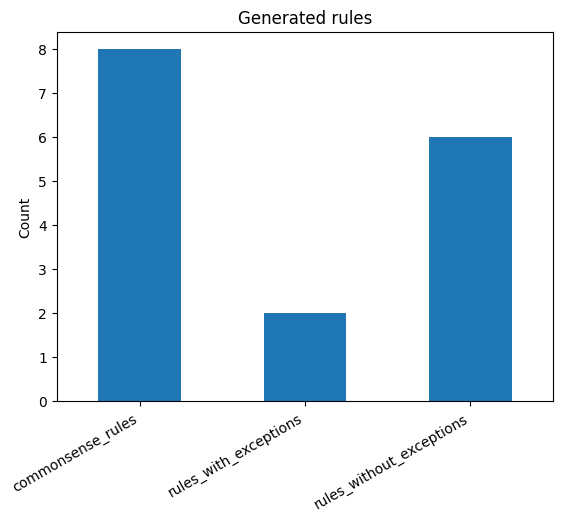

In [9]:
rule_summary.set_index("metric").plot(kind="bar", legend=False)
plt.title("Generated rules")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.show()

## Summary

This tutorial showed how to:

1. load a classification dataset,
2. prepare attributes and the target column,
3. train `ExceptionRulesClassifier`,
4. inspect commonsense, reference and exception rules,

The regression and survival tutorials follow the same structure.
